# Cosine Similarity between Truthseeker and Youtube data sets
We are aiming to quantify the semantic similarity between the Truthseeker and Youtube datasets using cosine similarity.

In [ ]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

In [ ]:
# File upload for both datasets
uploaded = files.upload()

In [ ]:
# Import dataframes directly from files in the Colab environment
truthseeker_df = pd.read_csv('/content/truthseeker.csv')
youtube_df = pd.read_csv('/content/youtube_data.csv')

## Implement Truthseeker data preprocessing
Specifically, creating a dataframe of real news and a dataframe of fake news from the Truthseeker set. Also, we preprocess the `tweet` column with lowercasing and punctuation, emoji, number, and whitespace removal.


In [ ]:
def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'@\S+', '', text) # Remove mentions starting with @
    # Remove emojis (regex to match most common emoji patterns)
    emoji_pattern = re.compile(
        "[   -   　​‌‍‎‏\uFEFF"
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    text = text.strip() # Remove leading/trailing whitespace
    return text

In [ ]:
# Add is_fake_news column, which is true if target and 3_label_majority_answer are different truthy values
truthseeker_df['is_fake_news'] = ((truthseeker_df['target'] == True) & (truthseeker_df['3_label_majority_answer'] == 'Disagree')) | \
                                   ((truthseeker_df['target'] == False) & (truthseeker_df['3_label_majority_answer'] == 'Agree'))

# Apply the preprocessing to the 'tweet' column in truthseeker_df
truthseeker_df['processed_tweet'] = truthseeker_df['tweet'].apply(preprocess_text)

print("DataFrame with 'is_fake_news' and 'processed_tweet' columns:")
print(truthseeker_df[['target', '3_label_majority_answer', 'is_fake_news', 'tweet', 'processed_tweet']].head())

DataFrame with 'is_fake_news' and 'processed_tweet' columns:
   target 3_label_majority_answer  is_fake_news  \
0    True                   Agree         False   
1    True                   Agree         False   
2    True                   Agree         False   
3    True                   Agree         False   
4    True                   Agree         False   

                                               tweet  \
0  @POTUS Biden Blunders - 6 Month Update\n\nInfl...   
1  @S0SickRick @Stairmaster_ @6d6f636869 Not as m...   
2  THE SUPREME COURT is siding with super rich pr...   
3  @POTUS Biden Blunders\n\nBroken campaign promi...   
4  @OhComfy I agree. The confluence of events rig...   

                                     processed_tweet  
0  potus biden blunders   month update\n\ninflati...  
1  ssickrick stairmaster df not as many people ar...  
2  the supreme court is siding with super rich pr...  
3  potus biden blunders\n\nbroken campaign promis...  
4  ohcomfy i agree t

In [ ]:
# Split the data into 2 dataframes, one for real and one for fake news
truthseeker_real_df = truthseeker_df[truthseeker_df['is_fake_news'] == False].copy()
truthseeker_fake_df = truthseeker_df[truthseeker_df['is_fake_news'] == True].copy()

print("Real News DataFrame Info:")
truthseeker_real_df.info()
print("\nReal News DataFrame Head:")
print(truthseeker_real_df.head())

print("\nFake News DataFrame Info:")
truthseeker_fake_df.info()
print("\nFake News DataFrame Head:")
print(truthseeker_fake_df.head())

Real News DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 68985 entries, 0 to 134168
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               68985 non-null  int64  
 1   author                   68985 non-null  object 
 2   statement                68985 non-null  object 
 3   target                   68985 non-null  bool   
 4   BinaryNumTarget          68985 non-null  float64
 5   manual_keywords          68985 non-null  object 
 6   tweet                    68985 non-null  object 
 7   5_label_majority_answer  68985 non-null  object 
 8   3_label_majority_answer  68985 non-null  object 
 9   is_fake_news             68985 non-null  bool   
 10  processed_tweet          68985 non-null  object 
dtypes: bool(2), float64(1), int64(1), object(7)
memory usage: 5.4+ MB

Real News DataFrame Head:
   Unnamed: 0      author                                          st

## Implement YouTube Data Preprocessing

We're processing the 'title' column, lowercasing and removing punctuation, emojis, numbers, and whitespace.

In [ ]:
import re
import string

youtube_df['processed_title'] = youtube_df['title'].apply(preprocess_text)

print("YouTube DataFrame with processed titles:")
display(youtube_df[['title', 'processed_title']].head())

YouTube DataFrame with processed titles:


,title,processed_title
0,VonOff 1700 - I Tried ft BigOpp (Official Video),vonoff i tried ft bigopp official video
1,Mortal Kombat II | Official Trailer II,mortal kombat ii official trailer ii
2,🔴LIVE | RV THERE YET NEW MAP w/ Cloakzy & Ging...,live rv there yet new map w cloakzy gingy o...
3,Aaya Sher - Lyrical | The Paradise | Nani | An...,aaya sher lyrical the paradise nani anirud...
4,T.I. - “Let ‘Em Know” (Official Trailer) [Dir....,ti “let ‘em know” official trailer dir hype w...


## Word2Vec Model Loading and Vector Generation

First, we'll install `gensim` and load the pre-trained Word2Vec model (`word2vec-google-news-300`). This model is quite large and might take some time to download if not already cached.

In [ ]:
# Install gensim if not already installed.
# Using %pip in a cell ensures it's installed in the Colab environment.
%pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.0 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
import gensim.models
import os # To check if file exists

model_path = 'word2vec-google-news-300.bin'

try:
    # Check if the model file exists locally
    if os.path.exists(model_path):
        loaded_word2vec_model = gensim.models.KeyedVectors.load(model_path)
        print("Word2Vec model loaded from saved file.")
    else:
        # If not found, download it
        print("Downloading Word2Vec model. This may take a while...")
        word2vec_model = api.load("word2vec-google-news-300")
        print("Word2Vec model downloaded.")
        word2vec_model.save(model_path)
        print(f"Word2Vec model saved to {model_path}")
        loaded_word2vec_model = word2vec_model

except Exception as e:
    # If loading or initial download fails, attempt re-download.
    # This catch block specifically handles potential issues during loading from disk or initial download
    print(f"Error with Word2Vec model: {e}. Attempting to re-download in case of corruption or incomplete download.")
    print("Downloading Word2Vec model. This may take a while...")
    word2vec_model = api.load("word2vec-google-news-300")
    print("Word2Vec model re-downloaded.")

    # Save the re-downloaded model for future use
    word2vec_model.save(model_path)
    print(f"Word2Vec model re-saved to {model_path}")

    loaded_word2vec_model = word2vec_model # Assign the re-downloaded model

embeddings_index = loaded_word2vec_model # for compatibility with existing code
print(f'Found {len(embeddings_index.key_to_index)} word vectors.')

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model downloaded.
Word2Vec model saved to word2vec-google-news-300.bin
Found 3000000 word vectors.


Now, we tokenize the text from `truthseeker_df` and `youtube_df` into individual words using `nltk.word_tokenize`.

Then, we generate a vector for each text entry by averaging the Word2Vec embeddings of its constituent words, skipping words not in the vocabulary.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Explicitly download punkt_tab
from nltk.tokenize import word_tokenize
import numpy as np # Import numpy as it's used in get_document_vector

def get_document_vector(text, model):
    if not isinstance(text, str): # Handle non-string inputs
        return np.zeros(model.vector_size)

    words = word_tokenize(text)
    # Filter out words not in the model's vocabulary
    word_vectors = [model[word] for word in words if word in model.key_to_index]

    if not word_vectors:
        # Return a zero vector if no words are found in the model's vocabulary
        return np.zeros(model.vector_size)

    return np.mean(word_vectors, axis=0)


# Generate Word2Vec vectors for Truthseeker real news
truthseeker_real_df['vector'] = truthseeker_real_df['processed_tweet'].apply(lambda x: get_document_vector(x, embeddings_index))

# Generate Word2Vec vectors for Truthseeker fake news
truthseeker_fake_df['vector'] = truthseeker_fake_df['processed_tweet'].apply(lambda x: get_document_vector(x, embeddings_index))

# Generate Word2Vec vectors for YouTube titles
youtube_df['vector'] = youtube_df['processed_title'].apply(lambda x: get_document_vector(x, embeddings_index))

print("Vectors generated for truthseeker_real_df, truthseeker_fake_df, and youtube_df.")

# Display the first few rows with vectors to confirm
print("Truthseeker Real DataFrame with vectors (head):")
display(truthseeker_real_df[['processed_tweet', 'vector']].head())

print("Truthseeker Fake DataFrame with vectors (head):")
display(truthseeker_fake_df[['processed_tweet', 'vector']].head())

print("YouTube DataFrame with vectors (head):")
display(youtube_df[['processed_title', 'vector']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Vectors generated for truthseeker_real_df, truthseeker_fake_df, and youtube_df.
Truthseeker Real DataFrame with vectors (head):


,processed_tweet,vector
0,potus biden blunders month update\n\ninflati...,"[-0.02224993, 0.09212734, -0.0031354632, 0.131..."
1,ssickrick stairmaster df not as many people ar...,"[0.064700395, 0.027047964, 0.033167914, 0.1113..."
2,the supreme court is siding with super rich pr...,"[0.08136082, 0.034588814, 0.02016449, 0.091521..."
3,potus biden blunders\n\nbroken campaign promis...,"[-0.019510323, 0.079373606, 0.0053362167, 0.09..."
4,ohcomfy i agree the confluence of events right...,"[0.008612534, 0.021531729, 0.06153659, 0.12884..."


Truthseeker Fake DataFrame with vectors (head):


,processed_tweet,vector
15,riguy paulsorrentino potus trump didnt attempt...,"[0.025833933, 0.022107927, 0.077277735, 0.1215..."
20,jimjordan gym remember when donald trump said ...,"[0.03546281, 0.015766686, 0.06397664, 0.115288..."
48,insane joebidens cdc unconstitutionally extend...,"[0.021760598, 0.023921428, 0.05787776, 0.12417..."
55,stellaparton potus biden blunders month upda...,"[-0.02859138, 0.09496442, -0.0022798425, 0.131..."
65,gettoshakespear shannonsharpe well i certainly...,"[0.021819286, 0.00581712, 0.02702136, 0.138455..."


YouTube DataFrame with vectors (head):


,processed_title,vector
0,vonoff i tried ft bigopp official video,"[0.003540039, 0.017938232, 0.039355468, 0.0188..."
1,mortal kombat ii official trailer ii,"[0.0641276, -0.019856771, 0.056233723, 0.07698..."
2,live rv there yet new map w cloakzy gingy o...,"[0.05809784, -0.028808594, 0.016368866, 0.0702..."
3,aaya sher lyrical the paradise nani anirud...,"[0.052978516, 0.04547119, 0.12670898, 0.108561..."
4,ti “let ‘em know” official trailer dir hype w...,"[0.12236871, 0.035508897, 0.04949273, 0.032470..."


# Calculating Cosine Similarity
We compute the cosine similarity between each YouTube title vector and the aggregated vectors from both `truthseeker_real_df` and `truthseeker_fake_df`.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Aggregate vectors for real and fake news from Truthseeker
# Ensure to handle cases where there might be no valid vectors (e.g., all words out of vocabulary)
real_news_vectors = np.array(truthseeker_real_df['vector'].tolist())
fake_news_vectors = np.array(truthseeker_fake_df['vector'].tolist())

# Filter out zero vectors if they exist (indicating no words were found in the model)
real_news_vectors_filtered = real_news_vectors[~np.all(real_news_vectors == 0, axis=1)]
fake_news_vectors_filtered = fake_news_vectors[~np.all(fake_news_vectors == 0, axis=1)]

# Compute average vectors for real and fake news
if len(real_news_vectors_filtered) > 0:
    avg_real_news_vector = np.mean(real_news_vectors_filtered, axis=0)
else:
    avg_real_news_vector = np.zeros(embeddings_index.vector_size)
    print("Warning: No valid real news vectors found for averaging.")

if len(fake_news_vectors_filtered) > 0:
    avg_fake_news_vector = np.mean(fake_news_vectors_filtered, axis=0)
else:
    avg_fake_news_vector = np.zeros(embeddings_index.vector_size)
    print("Warning: No valid fake news vectors found for averaging.")

# Calculate cosine similarity for each YouTube title
youtube_df['similarity_to_real'] = youtube_df['vector'].apply(
    lambda x: cosine_similarity(x.reshape(1, -1), avg_real_news_vector.reshape(1, -1))[0][0]
)
youtube_df['similarity_to_fake'] = youtube_df['vector'].apply(
    lambda x: cosine_similarity(x.reshape(1, -1), avg_fake_news_vector.reshape(1, -1))[0][0]
)

print("Cosine similarity calculations complete.")
print("YouTube DataFrame with similarity scores (head):")
display(youtube_df[['title', 'processed_title', 'similarity_to_real', 'similarity_to_fake']].head())

Cosine similarity calculations complete.
YouTube DataFrame with similarity scores (head):


,title,processed_title,similarity_to_real,similarity_to_fake
0,VonOff 1700 - I Tried ft BigOpp (Official Video),vonoff i tried ft bigopp official video,0.503342,0.515243
1,Mortal Kombat II | Official Trailer II,mortal kombat ii official trailer ii,0.390846,0.390622
2,🔴LIVE | RV THERE YET NEW MAP w/ Cloakzy & Ging...,live rv there yet new map w cloakzy gingy o...,0.641078,0.651347
3,Aaya Sher - Lyrical | The Paradise | Nani | An...,aaya sher lyrical the paradise nani anirud...,0.384893,0.397512
4,T.I. - “Let ‘Em Know” (Official Trailer) [Dir....,ti “let ‘em know” official trailer dir hype w...,0.567723,0.591299


Finally, we analyze the distribution of the similarity scores.

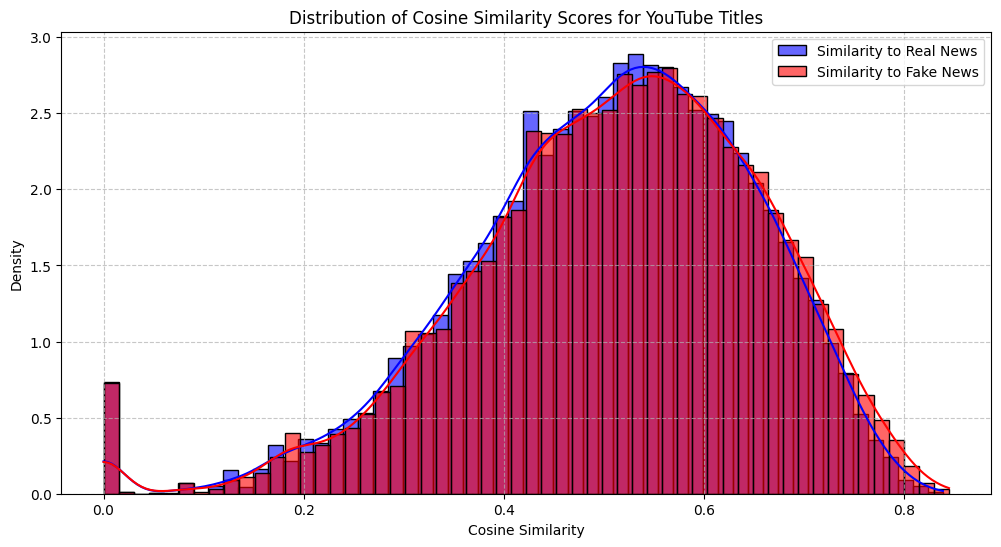

Descriptive statistics for similarity scores:
Similarity to Real News:
count    16400.000000
mean         0.504333
std          0.144330
min          0.000000
25%          0.416622
50%          0.517772
75%          0.609144
max          0.838436
Name: similarity_to_real, dtype: float64

Similarity to Fake News:
count    16400.000000
mean         0.512026
std          0.146847
min          0.000000
25%          0.423788
50%          0.524417
75%          0.617655
max          0.844524
Name: similarity_to_fake, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(youtube_df['similarity_to_real'], color='blue', label='Similarity to Real News', kde=True, stat='density', alpha=0.6)
sns.histplot(youtube_df['similarity_to_fake'], color='red', label='Similarity to Fake News', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Cosine Similarity Scores for YouTube Titles')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Descriptive statistics for similarity scores:")
print("Similarity to Real News:")
print(youtube_df['similarity_to_real'].describe())
print("\nSimilarity to Fake News:")
print(youtube_df['similarity_to_fake'].describe())

## Filtering YouTube Dataset for News-Related Content

To make the comparison more relevant, we filter the YouTube dataset to include only videos that are likely news-related. We'll do this by searching for a list of news-specific keywords in the `title`, `tags`, or `description` of each video.

In [ ]:
# Define a list of news-related keywords
news_keywords = [
    'news', 'breaking news', 'report', 'reporter', 'journalism', 'current events',
    'politics', 'election', 'government', 'economy', 'finance', 'market',
    'world affairs', 'international news', 'local news', 'update',
    'analysis', 'commentary', 'investigation', 'exclusive', 'interview',
    'press conference', 'crisis', 'disaster', 'conflict', 'war', 'peace',
    'health', 'science', 'technology', 'environment', 'climate change'
]

def is_news_related(row, keywords):
    # Combine title, description, and tags for keyword search
    text_to_check = str(row['title']) + ' ' + str(row['description']) + ' ' + str(row['tags'])
    text_to_check = text_to_check.lower() # Ensure lowercasing for consistent matching
    for keyword in keywords:
        if keyword in text_to_check:
            return True
    return False

# Apply the filter to create a new DataFrame
youtube_news_df = youtube_df[youtube_df.apply(lambda row: is_news_related(row, news_keywords), axis=1)].copy()

print(f"Original YouTube dataset size: {len(youtube_df)}")
print(f"Filtered YouTube news dataset size: {len(youtube_news_df)}")

display(youtube_news_df[['title', 'description', 'tags', 'processed_title']].head())

Original YouTube dataset size: 16400
Filtered YouTube news dataset size: 4368


,title,description,tags,processed_title
1,Mortal Kombat II | Official Trailer II,The wait is almost over! Mortal Kombat II arri...,2026|Action|Adeline Rudolph|Adventure|Battle|C...,mortal kombat ii official trailer ii
3,Aaya Sher - Lyrical | The Paradise | Nani | An...,"For more latest songs & videos, subscribe 👉 ht...",Anirudh Ravichander|The Paradise Theme OST|The...,aaya sher lyrical the paradise nani anirud...
5,Sirius - No more Brawl Stars! (Brawl Stars Ani...,"🫷 Sirius, The First Star of Starr Park is here...",brawl stars|mobile game|mobile strategy game|m...,sirius no more brawl stars brawl stars animation
7,MORTAL KOMBAT 2 Official Trailer 2 (2026),Official Mortal Kombat 2 Movie Trailer 2 2026 ...,2026|Action|Chin Han|FIght|Hiroyuki Sanada|Kar...,mortal kombat official trailer
11,The Game You Cannot Escape - Half Life & Black...,Go to https://buyraycon.com/IFAVGOPEN to get 1...,half life|valve|half life 2|quake|doom|portal|...,the game you cannot escape half life black m...


Now that we have a filtered YouTube dataset (`youtube_news_df`), we to regenerate the Word2Vec vectors for these titles. After that, we recalculate the cosine similarities with this more focused dataset.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Generate Word2Vec vectors for the filtered YouTube news titles
youtube_news_df['vector'] = youtube_news_df['processed_title'].apply(lambda x: get_document_vector(x, embeddings_index))

print("Vectors generated for youtube_news_df.")

# Recalculate cosine similarity for each filtered YouTube title
youtube_news_df['similarity_to_real'] = youtube_news_df['vector'].apply(
    lambda x: cosine_similarity(x.reshape(1, -1), avg_real_news_vector.reshape(1, -1))[0][0]
)
youtube_news_df['similarity_to_fake'] = youtube_news_df['vector'].apply(
    lambda x: cosine_similarity(x.reshape(1, -1), avg_fake_news_vector.reshape(1, -1))[0][0]
)

print("Cosine similarity calculations complete for filtered YouTube data.")
print("Filtered YouTube DataFrame with similarity scores (head):")
display(youtube_news_df[['title', 'processed_title', 'similarity_to_real', 'similarity_to_fake']].head())

Vectors generated for youtube_news_df.
Cosine similarity calculations complete for filtered YouTube data.
Filtered YouTube DataFrame with similarity scores (head):


,title,processed_title,similarity_to_real,similarity_to_fake
1,Mortal Kombat II | Official Trailer II,mortal kombat ii official trailer ii,0.390846,0.390622
3,Aaya Sher - Lyrical | The Paradise | Nani | An...,aaya sher lyrical the paradise nani anirud...,0.384893,0.397512
5,Sirius - No more Brawl Stars! (Brawl Stars Ani...,sirius no more brawl stars brawl stars animation,0.408558,0.407111
7,MORTAL KOMBAT 2 Official Trailer 2 (2026),mortal kombat official trailer,0.392525,0.408794
11,The Game You Cannot Escape - Half Life & Black...,the game you cannot escape half life black m...,0.726638,0.731279


Finally, we analyze the distribution of these new similarity scores from the filtered YouTube dataset.

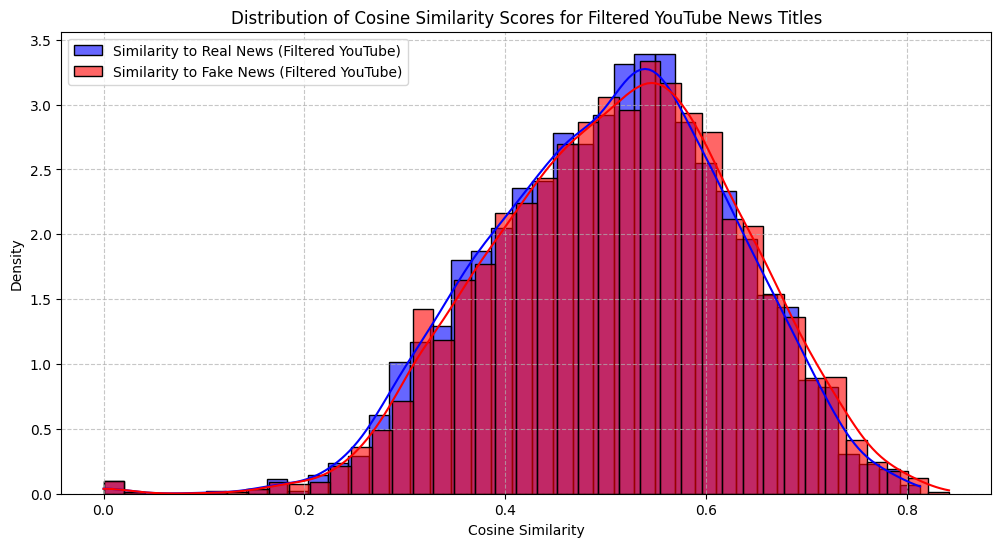

Descriptive statistics for filtered similarity scores:
Similarity to Real News (Filtered):
count    4368.000000
mean        0.503672
std         0.120486
min         0.000000
25%         0.420078
50%         0.512086
75%         0.589179
max         0.812647
Name: similarity_to_real, dtype: float64

Similarity to Fake News (Filtered):
count    4368.000000
mean        0.511787
std         0.121906
min         0.000000
25%         0.427338
50%         0.518153
75%         0.598547
max         0.841542
Name: similarity_to_fake, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(youtube_news_df['similarity_to_real'], color='blue', label='Similarity to Real News (Filtered YouTube)', kde=True, stat='density', alpha=0.6)
sns.histplot(youtube_news_df['similarity_to_fake'], color='red', label='Similarity to Fake News (Filtered YouTube)', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Cosine Similarity Scores for Filtered YouTube News Titles')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Descriptive statistics for filtered similarity scores:")
print("Similarity to Real News (Filtered):")
print(youtube_news_df['similarity_to_real'].describe())
print("\nSimilarity to Fake News (Filtered):")
print(youtube_news_df['similarity_to_fake'].describe())